In [ ]:
import anndata as ad
import scanpy as sc
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde
import matplotlib.colors as mcolors
import matplotlib.collections as mcoll

# Compare region scores (average gene expression across genes in region) for samples with and without clustered SV event at region 

In [32]:
# load data
samples = {
    "SJOS001108_M1": "../../data/st_jude/SJOS001108_M1.h5ad", # TP53 upstream cluster
    "SJOS016015_D1": "../../data/st_jude/SJOS016015_D1.h5ad", # TP53 upstream cluster (has ecDNA)
    "SJOS030597_D1": "../../data/st_jude/SJOS030597_D1.h5ad", # MYC cluster
    "SJOS012409_D1": "../../data/st_jude/SJOS012409_D1.h5ad", # no hotspot clusters
    "SJOS046149_R1": "../../data/st_jude/SJOS046149_R1.h5ad", # CCND3 cluster
    "SJOS001107_M2": "../../data/st_jude/SJOS001107_M2.h5ad", # TP53 upstream cluster, CCND3 cluster (has ecDNA)
    "SJOS063833_D2": "../../data/st_jude/SJOS063833_D2.h5ad", # MYC cluster
    "SJOS030101_D1": "../../data/st_jude/SJOS030101_D1.h5ad", # TP53 upstream cluster, CCND3 cluster (has ecDNA)
    "CCG1106_086_T1": "../../data/dfci/expression-data_scrna_dfci_tumor_expr_CCG1106_086_T1.h5ad", # TP53 upstream cluster, CCND3 cluster (has ecDNA)
    "17_439_00067_T2": "../../data/dfci/expression-data_scrna_dfci_tumor_expr_17_439_00067_T2.h5ad", # no hotspot clusters
    "CCG1106_005_T1": "../../data/dfci/expression-data_scrna_dfci_tumor_expr_CCG1106_005_T1.h5ad", # TP53 upstream cluster (has ecDNA)
    "CCG1106_075_T1": "../../data/dfci/expression-data_scrna_dfci_tumor_expr_CCG1106_075_T1.h5ad", # TP53 upstream cluster
    "CCG1106_083_T1": "../../data/dfci/expression-data_scrna_dfci_tumor_expr_CCG1106_083_T1.h5ad", # no hotspot clusters
    "CCG1106_084_T1": "../../data/dfci/expression-data_scrna_dfci_tumor_expr_CCG1106_084_T1.h5ad" # MYC cluster (has ecDNA)
}

# create combined anndata object
adatas = {}

for sample_id, filename in samples.items():
    sample_adata = sc.read_h5ad(filename)
    sample_adata.obs["sample"] = sample_id
    sample_adata.var_names_make_unique()
    sample_adata.obs_names_make_unique()
    
    # Normalization
    sc.pp.normalize_total(sample_adata, target_sum=1e4)
    sc.pp.log1p(sample_adata)
    
    adatas[sample_id] = sample_adata

adata = ad.concat(adatas, label="sample", join="outer", fill_value=0)
adata.obs_names_make_unique()

adata.obs['cohort'] = adata.obs['sample'].apply(
    lambda x: 'St_Jude' if x.startswith('SJOS') else 'DFCI'
)

hotspot_mapping = {
    "SJOS001108_M1": ["TP53_upstream"],
    "SJOS016015_D1": ["TP53_upstream"],
    "SJOS030597_D1": ["MYC"],
    "SJOS012409_D1": ["no_hotspot"],
    "SJOS046149_R1": ["CCND3"],
    "CCG1106_086_T1": ["TP53_upstream", "CCND3"],
    "17_439_00067_T2": ["no_hotspot"],
    "CCG1106_005_T1": ["TP53_upstream"],
    "CCG1106_075_T1": ["TP53_upstream"],
    "CCG1106_083_T1": ["no_hotspot"],
    "CCG1106_084_T1": ["MYC"],
    "SJOS001107_M2": ["TP53_upstream", "CCND3"],
    "SJOS063833_D2": ["MYC"],
    "SJOS030101_D1": ["TP53_upstream", "CCND3"]
}
adata.obs["hotspot_group"] = adata.obs["sample"].map(lambda x: ",".join(hotspot_mapping.get(x, [])))
adata.obs

/opt/anaconda3/lib/python3.13/site-packages/anndata/_core/anndata.py:1792: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo,total_counts_hb,pct_counts_hb,n_genes,n_counts,doublet_scores,predicted_doublets,doublet_info,sample,cell_type,cohort,hotspot_group
TGAGTCAAGTCGAAGC,5785,13699.0,1166.0,8.511570,411.0,3.000219,0.0,0.000000,5785,13699.0,0.193777,false,False,SJOS001108_M1,Osteoblast,St_Jude,TP53_upstream
AGTAGTCGTCACTCGG,4974,11368.0,1036.0,9.113300,274.0,2.410274,0.0,0.000000,4974,11368.0,0.147982,false,False,SJOS001108_M1,Osteoblast,St_Jude,TP53_upstream
TACTTACCAAAGGTTA,4446,9749.0,1272.0,13.047492,319.0,3.272130,0.0,0.000000,4446,9749.0,0.053942,false,False,SJOS001108_M1,Osteoblast,St_Jude,TP53_upstream
TTACCGCTCCTCTAGC,4106,8250.0,748.0,9.066667,252.0,3.054545,1.0,0.012121,4106,8250.0,0.053942,false,False,SJOS001108_M1,Osteoblast,St_Jude,TP53_upstream
CAGCCAGCAGGATTCT,3416,6269.0,655.0,10.448237,297.0,4.737598,0.0,0.000000,3416,6269.0,0.045581,false,False,SJOS001108_M1,Osteoblast,St_Jude,TP53_upstream
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CACAAACAGCTAACAA,346,603.0,1.0,0.165837,1.0,0.165837,0.0,0.000000,346,603.0,0.005864,false,False,CCG1106_084_T1,Osteoblast,DFCI,MYC
CGAGCCAAGCTATGCT,358,615.0,1.0,0.162602,1.0,0.162602,1.0,0.162602,358,615.0,0.015892,false,False,CCG1106_084_T1,Osteoblast,DFCI,MYC
TGGCGCATCTTGTACT,328,568.0,2.0,0.352113,77.0,13.556338,1.0,0.176056,328,568.0,0.038844,false,False,CCG1106_084_T1,Osteoblast,DFCI,MYC
CATATGGGTGTGGTTT,406,548.0,3.0,0.547445,1.0,0.182482,0.0,0.000000,406,548.0,0.026354,false,False,CCG1106_084_T1,Pericyte,DFCI,MYC


Processing MYC
Found 322 genes in region, 219 present in data
Cells with MYC event: 4103
Cells without MYC event: 42703
Mean score with event: 0.139
Mean score without event: 0.165


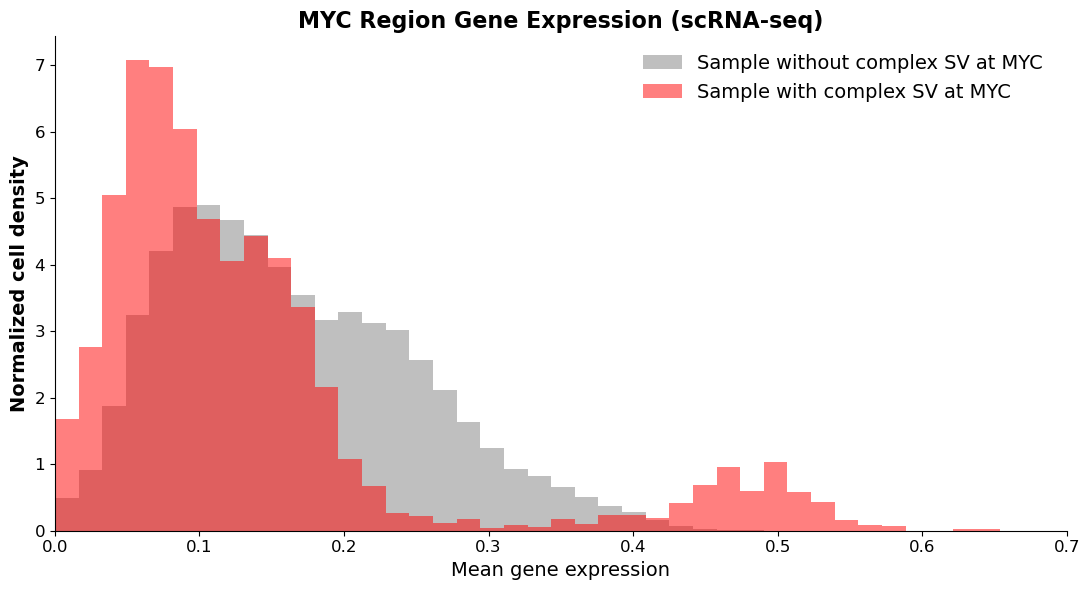

Processing CCND3
Found 266 genes in region, 207 present in data
Cells with CCND3 event: 17689
Cells without CCND3 event: 29117
Mean score with event: 0.176
Mean score without event: 0.079


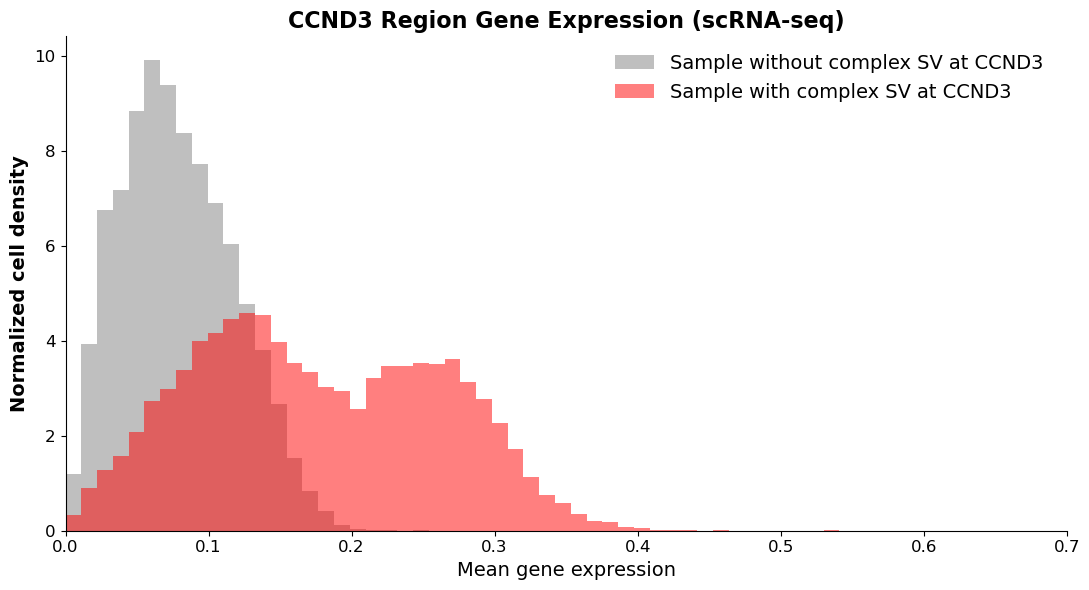

Processing TP53_upstream
Found 398 genes in region, 318 present in data
Cells with TP53_upstream event: 32723
Cells without TP53_upstream event: 14083
Mean score with event: 0.117
Mean score without event: 0.080


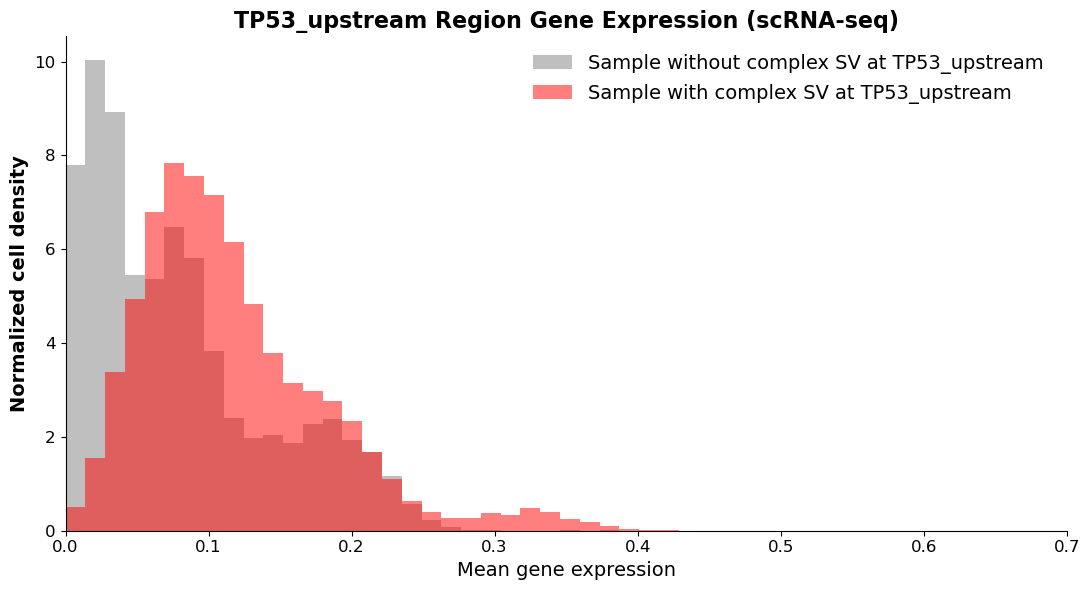

In [35]:
regions_of_interest = {
    "MYC": {"chrom": 8, "start": 99000000, "end": 137000000},
    "CCND3": {"chrom": 6, "start": 39000000, "end": 55000000}, 
    "TP53_upstream": {"chrom": 17, "start": 7000000, "end": 22000000},
}

# load gene annotations
gene_allelic_file = pd.read_csv("../../../bulk_RNA/data/gene_coordinates.txt", sep="\t")
gene_allelic_file['Chromosome/scaffold name'] = (gene_allelic_file['Chromosome/scaffold name'].replace({'X': '23', 'Y': '24'}))
gene_allelic_file['Chromosome/scaffold name'] = pd.to_numeric(gene_allelic_file['Chromosome/scaffold name'])
gene_allelic_file['Chromosome/scaffold name'] = gene_allelic_file['Chromosome/scaffold name'].astype(int)
gene_allelic_file = gene_allelic_file[(gene_allelic_file['Chromosome/scaffold name'] >= 1) & (gene_allelic_file['Chromosome/scaffold name'] <= 24)]

# loop through each region of interest
for gene_of_interest, region_info in regions_of_interest.items():
    print(f"Processing {gene_of_interest}")

    region_chrom = region_info["chrom"]
    region_start = region_info["start"]
    region_end = region_info["end"]
    
    # get genes in region
    genes_in_region = gene_allelic_file[
        (gene_allelic_file["Chromosome/scaffold name"] == region_chrom) &
        (gene_allelic_file["Gene start (bp)"] <= region_end) & 
        (gene_allelic_file["Gene end (bp)"] >= region_start)
    ]
    
    gene_names_list = genes_in_region["Gene name"].tolist()
    gene_names_list = [g for g in gene_names_list if pd.notna(g)]
    
    # filter to genes actually in the data
    genes_in_data = [g for g in gene_names_list if g in adata.var_names]
    print(f"Found {len(gene_names_list)} genes in region, {len(genes_in_data)} present in data")
    # save list of genes in region (used later for DEG analysis)
    pd.DataFrame({"gene": genes_in_data}).to_csv(f"../data/{gene_of_interest}_genes_in_region.txt", index=False)
    
    # mean expression across region genes for each cell
    region_data = adata[:, genes_in_data]
    if hasattr(region_data.X, 'toarray'):
        mean_expr = region_data.X.toarray().mean(axis=1)
    else:
        mean_expr = region_data.X.mean(axis=1)
    
    adata.obs[f'{gene_of_interest}_region_score'] = mean_expr
    
    # event status column (has this specific hotspot or not)
    adata.obs[f'has_{gene_of_interest}_event'] = adata.obs['hotspot_group'].apply(
    lambda x: gene_of_interest in x.split(",") if x else False
    )
    event_scores = adata.obs[adata.obs[f'has_{gene_of_interest}_event']][f'{gene_of_interest}_region_score']
    no_event_scores = adata.obs[~adata.obs[f'has_{gene_of_interest}_event']][f'{gene_of_interest}_region_score']
    
    print(f"Cells with {gene_of_interest} event: {len(event_scores)}")
    print(f"Cells without {gene_of_interest} event: {len(no_event_scores)}")
    print(f"Mean score with event: {event_scores.mean():.3f}")
    print(f"Mean score without event: {no_event_scores.mean():.3f}")
    
    # Plot histogram comparison
    fig, ax = plt.subplots(figsize=(11, 6))
    
    bins = np.linspace(
        min(event_scores.min(), no_event_scores.min()),
        max(event_scores.max(), no_event_scores.max()),
        50
    )
    
    ax.hist(no_event_scores, bins=bins, alpha=0.5, label=f'Sample without complex SV at {gene_of_interest} ', 
            color='gray', density=True)
    ax.hist(event_scores, bins=bins, alpha=0.5, label=f'Sample with complex SV at {gene_of_interest}', 
            color='red', density=True)
    ax.set_xlim(0, 0.7)
    ax.set_xlabel(f'Mean gene expression', fontsize=14)
    ax.set_ylabel('Normalized cell density', fontsize=14, fontweight='bold')
    ax.tick_params(axis='both', labelsize=12)
    ax.set_title(f'{gene_of_interest} Region Gene Expression (scRNA-seq)', fontsize=16, fontweight='bold')
    ax.legend(fontsize=14, loc='upper right', frameon=False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    plt.savefig(f'../outputs/plots/{gene_of_interest}_region_expression_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

/var/folders/l_/yt1nk3rj6rvgt0nnj_qtfs7m0000gn/T/ipykernel_879/63134697.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sample_has_event = df.groupby(sample_col)[event_col].any()


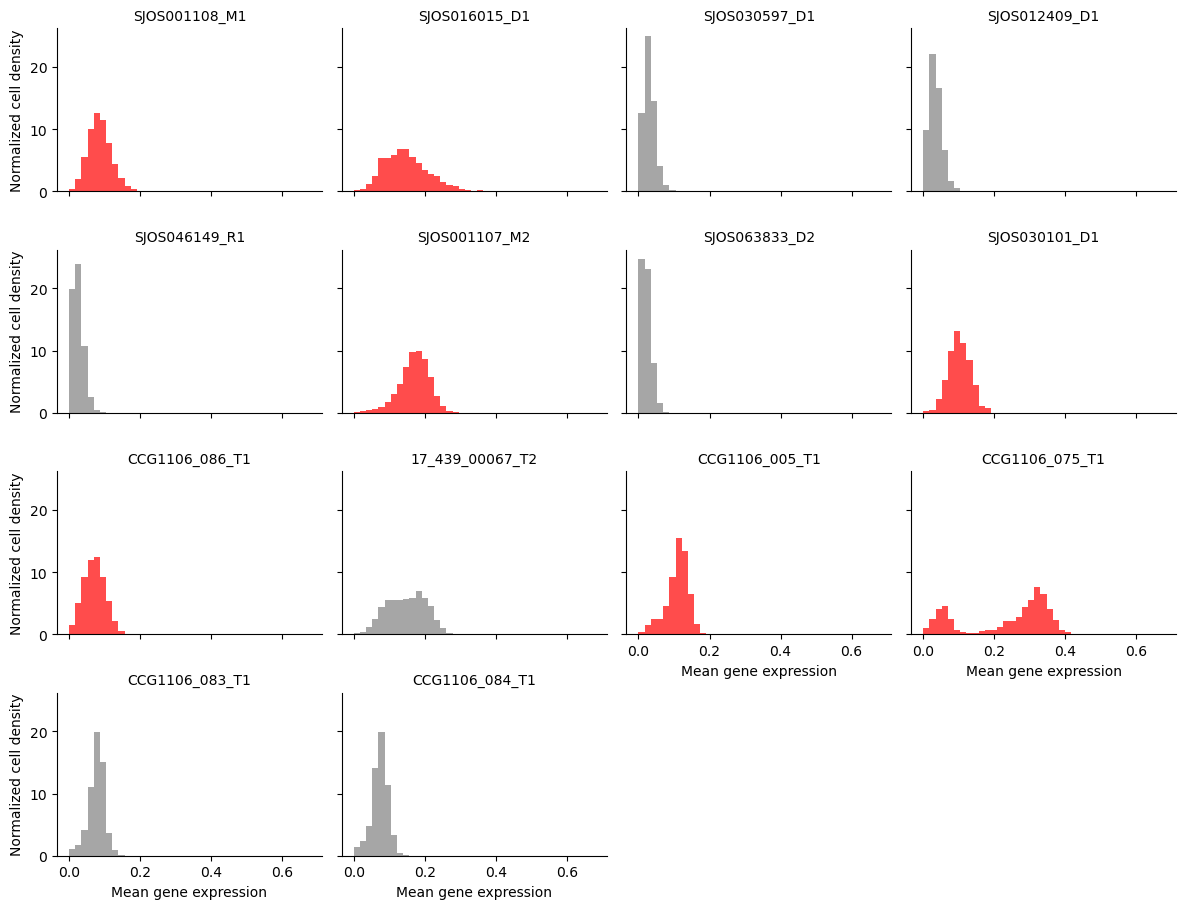

In [36]:
# plot sample-level region scores for a specific hotspot
gene_of_interest = "TP53_upstream"
sample_col = "sample"

score_col = f"{gene_of_interest}_region_score"
event_col = f"has_{gene_of_interest}_event"
df = adata.obs[[sample_col, score_col, event_col]].dropna().copy()
sample_has_event = df.groupby(sample_col)[event_col].any()
palette = {s: ("red" if sample_has_event.loc[s] else "gray") for s in sample_has_event.index}

# consistent bins across panels
bins = np.linspace(df[score_col].min(), df[score_col].max(), 40)

g = sns.FacetGrid(df, col=sample_col, col_wrap=4, sharex=True, sharey=True, height=2.3, aspect=1.3)

def hist_per_facet(data, **kwargs):
    s = data[sample_col].iloc[0]
    plt.hist(data[score_col], bins=bins, density=True, color=palette[s], alpha=0.7)

g.map_dataframe(hist_per_facet)
g.set_axis_labels("Mean gene expression", "Normalized cell density")
g.set_titles("{col_name}")
plt.tight_layout()
plt.show()

/var/folders/l_/yt1nk3rj6rvgt0nnj_qtfs7m0000gn/T/ipykernel_879/539548412.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sample_has_event = df.groupby(sample_col)[event_col].any()


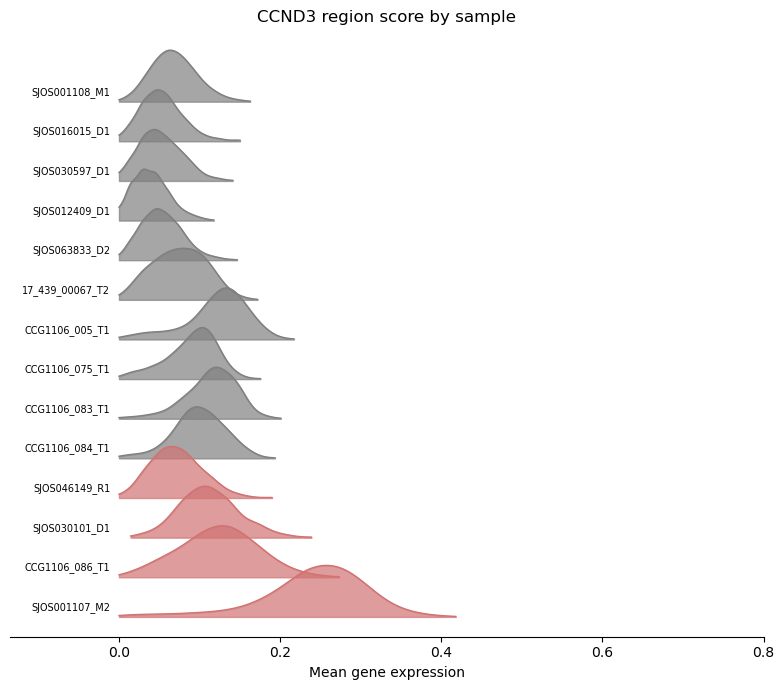

In [ ]:
# visualization for paper

gene_of_interest = "CCND3"
sample_col = "sample"

score_col = f"{gene_of_interest}_region_score"
event_col = f"has_{gene_of_interest}_event"
df = adata.obs[[sample_col, score_col, event_col]].dropna().copy()
sample_has_event = df.groupby(sample_col)[event_col].any()

# Sort: gray (no event) first, red (has event) on top
samples_no_event = [s for s in sample_has_event.index if not sample_has_event[s]]
samples_with_event = [s for s in sample_has_event.index if sample_has_event[s]]
ordered_samples = samples_no_event + samples_with_event  # event samples plotted last = on top

ordered_samples.remove("SJOS001107_M2")
ordered_samples.append("SJOS001107_M2")

x_min, x_max = df[score_col].min(), df[score_col].max()
x_grid = np.linspace(x_min, x_max, 300)

overlap = 1.3  # how much rows overlap (0 = no overlap, 1 = full height overlap)
n = len(ordered_samples)

fig, ax = plt.subplots(figsize=(8, n * 0.5))

for i, sample in enumerate(ordered_samples):
    sample_data = df[df[sample_col] == sample][score_col].values
    color = '#d17373' if sample_has_event[sample] else 'gray'
    
    if len(sample_data) > 1:
        s_min, s_max = sample_data.min(), sample_data.max()
        x_sample = x_grid[(x_grid >= s_min) & (x_grid <= s_max)]
        
        kde = gaussian_kde(sample_data, bw_method=0.3)
        y = kde(x_sample)
        
        # Trim tails where density is negligible
        threshold = y.max() * 0.01  # drop anything below 1% of peak density
        mask = y >= threshold
        x_sample = x_sample[mask]
        y = y[mask]
        
        y = y / y.max()
    else:
        x_sample = x_grid
        y = np.zeros_like(x_grid)

    baseline = n - i
    ax.fill_between(x_sample, baseline, baseline + y * overlap, color=color, alpha=0.7)
    ax.plot(x_sample, baseline + y * overlap, color=color, linewidth=1)
    ax.text(x_min - (x_max - x_min) * 0.02, baseline + 0.1, sample,
            ha='right', va='bottom', fontsize=7, color='black')

ax.set_xlim(x_min - (x_max - x_min) * 0.25, 0.8)
ax.set_ylim(0.5, n + overlap + 0.5)
ax.set_xlabel("Mean gene expression")
ax.set_yticks([])
ax.spines[['left', 'top', 'right']].set_visible(False)
ax.set_title(f"{gene_of_interest} region score by sample")

plt.tight_layout()
plt.savefig(f"../outputs/plots/{gene_of_interest}_all_samples_ridge_plot.pdf", dpi=300, bbox_inches='tight')
plt.show()

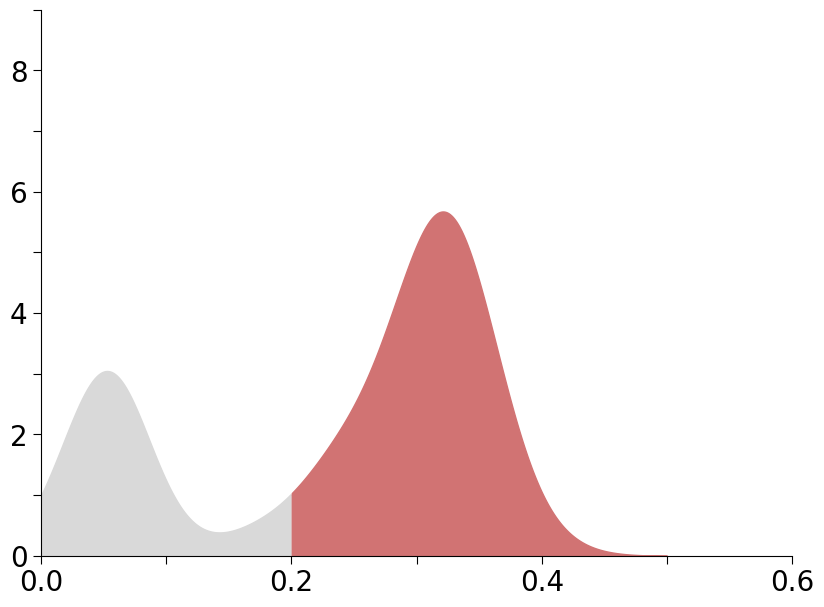

In [38]:
# visualization for paper
gene_of_interest = "TP53_upstream"
sample_to_plot = "CCG1106_075_T1"

score_col = f"{gene_of_interest}_region_score"
df = adata.obs[["sample", score_col]].dropna().copy()

fig, ax = plt.subplots(figsize=(8, 6))

all_kdes = []

scores = df[df["sample"] == sample_to_plot][score_col]
xs = np.linspace(scores.min(), 0.5, 500) # can also set to scores.max()
kde = gaussian_kde(scores, bw_method='scott')
all_kdes.append((xs, kde(xs), color, sample_id))

threshold = 0.2 # set to 0 for CCND3 sample
# split by threshold
xs_left = xs[xs <= threshold]
xs_right = xs[xs >= threshold]
ys = kde(xs)
ys_left = kde(xs_left)
ys_right = kde(xs_right)

# left of threshold
ax.fill_between(xs_left, ys_left, color="#d9d9d9ff")
ax.plot(xs_left, ys_left, color="#d9d9d9ff", linewidth=0)
# right of threshold
ax.fill_between(xs_right, ys_right, color="#d17373ff")
ax.plot(xs_right, ys_right, color="#d17373ff", linewidth=0)

plt.tight_layout()
fig.canvas.draw()

xticks = [t for t in ax.get_xticks() if ax.get_xlim()[0] <= t <= ax.get_xlim()[1]]
yticks = [t for t in ax.get_yticks() if t >= 0]
ax.tick_params(axis='both', labelsize=20, length=6)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_ylim(0, 9)
ax.set_xlim(xticks[0], 0.6)
ax.spines['bottom'].set_bounds(xticks[0], 0.6)
ax.spines['left'].set_bounds(0, 9)

for i, lab in enumerate(ax.get_xticklabels()):
    if i % 2 == 1:
        lab.set_visible(False)

for i, lab in enumerate(ax.get_yticklabels()):
    if i % 2 == 1:
        lab.set_visible(False)

plt.savefig(f'../outputs/plots/{sample_to_plot}_{gene_of_interest}_expression_comparison_paper.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Analysis of MYC sample (CCG1106_084_T1) 
Prepare input files for cytotrace

In [39]:
# for samples w/ MYC event, (1) load anndata for samples w/ event (2) label cells w/ MYC event (3) prepare files for cytotrace
sample_id = 'CCG1106_084_T1'
threshold = 0.35

# 1. Load raw counts
myc_sample_adata = sc.read_h5ad("../../data/dfci/expression-data_scrna_dfci_tumor_expr_CCG1106_084_T1.h5ad")
print(f"Raw data shape: {myc_sample_adata.shape}")

# 2. Normalize to calculate region scores
myc_sample_adata_norm = myc_sample_adata.copy()
sc.pp.normalize_total(myc_sample_adata_norm, target_sum=1e4)
sc.pp.log1p(myc_sample_adata_norm)

# 3. Calc MYC region score
region_chrom = 8
region_start = 99000000 
region_end = 137000000 

genes_in_region = gene_allelic_file[
    (gene_allelic_file["Chromosome/scaffold name"] == region_chrom) &
    (gene_allelic_file["Gene start (bp)"] <= region_end) & 
    (gene_allelic_file["Gene end (bp)"] >= region_start)
]
gene_names_list = genes_in_region["Gene name"].tolist()
gene_names_list = [g for g in gene_names_list if pd.notna(g)]
genes_in_data = [g for g in gene_names_list if g in myc_sample_adata_norm.var_names]
print(f"Found {len(genes_in_data)} genes in MYC region")

# Calculate region score
region_data = myc_sample_adata_norm[:, genes_in_data]
if hasattr(region_data.X, 'toarray'):
    mean_expr = region_data.X.toarray().mean(axis=1)
else:
    mean_expr = region_data.X.mean(axis=1)

# Add labels to raw adata (we need to use raw counts for cytotrace)
myc_sample_adata.obs['MYC_region_score'] = mean_expr
myc_sample_adata.obs['MYC_amplified'] = mean_expr > threshold
print(f"\nMYC amplified cells: {myc_sample_adata.obs['MYC_amplified'].sum()}")
print(f"Non-amplified cells: {(~myc_sample_adata.obs['MYC_amplified']).sum()}")

# Create expression matrix
expr_matrix = pd.DataFrame(
    myc_sample_adata.X.toarray().T,
    index=myc_sample_adata.var_names,
    columns=myc_sample_adata.obs_names
)

# Create phenotype file
phenotype = pd.DataFrame({
    'cell_id': myc_sample_adata.obs_names,
    'phenotype': myc_sample_adata.obs['MYC_amplified'].map({
        True: 'MYC_amplified',
        False: 'Non_amplified'
    })
})

expr_matrix.to_csv(f'../../cytotrace/data/{sample_id}_expression_matrix_raw.txt', sep='\t')
phenotype.to_csv(f'../../cytotrace/data/{sample_id}_phenotype.txt', sep='\t', header=True, index=False)
myc_sample_adata.obs

Raw data shape: (1273, 26220)
Found 207 genes in MYC region

MYC amplified cells: 410
Non-amplified cells: 863


,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo,total_counts_hb,pct_counts_hb,n_genes,n_counts,doublet_scores,predicted_doublets,doublet_info,sample,cell_type,MYC_region_score,MYC_amplified
ATGCGATAGAACAACT,5486,36779.0,6166.0,16.765002,359.0,0.976100,0.0,0.000000,5486,36779.0,0.032841,false,False,SCPCL000687,Osteoblast,0.598986,True
TATGCCCGTTATTCTC,5619,30422.0,332.0,1.091315,138.0,0.453619,2.0,0.006574,5619,30422.0,0.031076,false,False,SCPCL000687,Osteoblast,0.499265,True
CGACTTCTCCGCAAGC,5987,30423.0,397.0,1.304934,112.0,0.368143,0.0,0.000000,5987,30423.0,0.017846,false,False,SCPCL000687,Osteoblast,0.551736,True
CACACAACACGGCGTT,5556,27601.0,160.0,0.579689,186.0,0.673889,1.0,0.003623,5556,27601.0,0.029412,false,False,SCPCL000687,Osteoblast,0.528923,True
GATCGCGAGGCTCAGA,5996,26873.0,24.0,0.089309,173.0,0.643769,1.0,0.003721,5996,26873.0,0.019987,false,False,SCPCL000687,Osteoblast,0.430535,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CACAAACAGCTAACAA,346,603.0,1.0,0.165837,1.0,0.165837,0.0,0.000000,346,603.0,0.005864,false,False,SCPCL000687,Osteoblast,0.013942,False
CGAGCCAAGCTATGCT,358,615.0,1.0,0.162602,1.0,0.162602,1.0,0.162602,358,615.0,0.015892,false,False,SCPCL000687,Osteoblast,0.000000,False
TGGCGCATCTTGTACT,328,568.0,2.0,0.352113,77.0,13.556338,1.0,0.176056,328,568.0,0.038844,false,False,SCPCL000687,Osteoblast,0.118090,False
CATATGGGTGTGGTTT,406,548.0,3.0,0.547445,1.0,0.182482,0.0,0.000000,406,548.0,0.026354,false,False,SCPCL000687,Pericyte,0.032106,False


DEG analysis

In [40]:
# Add group labels as category
myc_sample_adata.obs['MYC_status'] = myc_sample_adata.obs['MYC_amplified'].map({
    True: 'MYC_amplified', 
    False: 'Non_amplified'
}).astype('category')

# Normalize for DEG analysis
myc_sample_adata_norm = myc_sample_adata.copy()
sc.pp.normalize_total(myc_sample_adata_norm, target_sum=1e4)
sc.pp.log1p(myc_sample_adata_norm)

# Run differential expression (Wilcoxon rank-sum test)
sc.tl.rank_genes_groups(myc_sample_adata_norm, groupby='MYC_status', method='wilcoxon', reference='Non_amplified')

# Get results as DataFrame
deg_results = sc.get.rank_genes_groups_df(myc_sample_adata_norm, group='MYC_amplified')
deg_results.to_csv("../outputs/deg_analysis/MYC_amplified_vs_non_wilcoxon_DEGs.csv", index=False)

# Filter significant DEGs
sig_degs = deg_results[(deg_results['pvals_adj'] < 0.01) & 
                       (abs(deg_results['logfoldchanges']) > 1)]

print(f"Significant DEGs: {len(sig_degs)}")
print(f"  Upregulated in MYC amplified: {(sig_degs['logfoldchanges'] > 0).sum()}")
print(f"  Downregulated: {(sig_degs['logfoldchanges'] < 0).sum()}")

# Load the MYC region genes
myc_region_genes = pd.read_csv("../data/MYC_genes_in_region.txt")['gene'].dropna().tolist()

# Add column indicating if gene is in MYC region
sig_degs['in_MYC_region'] = sig_degs['names'].isin(myc_region_genes)

# Check how many DEGs are in the region
print(f"DEGs in MYC region: {sig_degs['in_MYC_region'].sum()}")
print(f"DEGs outside MYC region: {(~sig_degs['in_MYC_region']).sum()}")

sig_degs.to_csv("../outputs/deg_analysis/MYC_amplified_vs_non_wilcoxon_sig_DEGs.csv", index=False)

Significant DEGs: 3619
  Upregulated in MYC amplified: 2911
  Downregulated: 708
DEGs in MYC region: 84
DEGs outside MYC region: 3535


/var/folders/l_/yt1nk3rj6rvgt0nnj_qtfs7m0000gn/T/ipykernel_879/1318796044.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sig_degs['in_MYC_region'] = sig_degs['names'].isin(myc_region_genes)


/var/folders/l_/yt1nk3rj6rvgt0nnj_qtfs7m0000gn/T/ipykernel_879/1481350656.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Non-amplified', 'MYC amplified'])
/var/folders/l_/yt1nk3rj6rvgt0nnj_qtfs7m0000gn/T/ipykernel_879/1481350656.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Non-amplified', 'MYC amplified'])
/var/folders/l_/yt1nk3rj6rvgt0nnj_qtfs7m0000gn/T/ipykernel_879/1481350656.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(['Non-amplified', 'MYC amplified'])
/var/folders/l_/yt1nk3rj6rvgt0nnj_qtfs7m0000gn/T/ipykernel_879/1481350656.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or 

MYC amplified mean: 4169.1
Non-amplified mean: 2366.1
Fold change: 1.762
Log2 fold change: 0.817


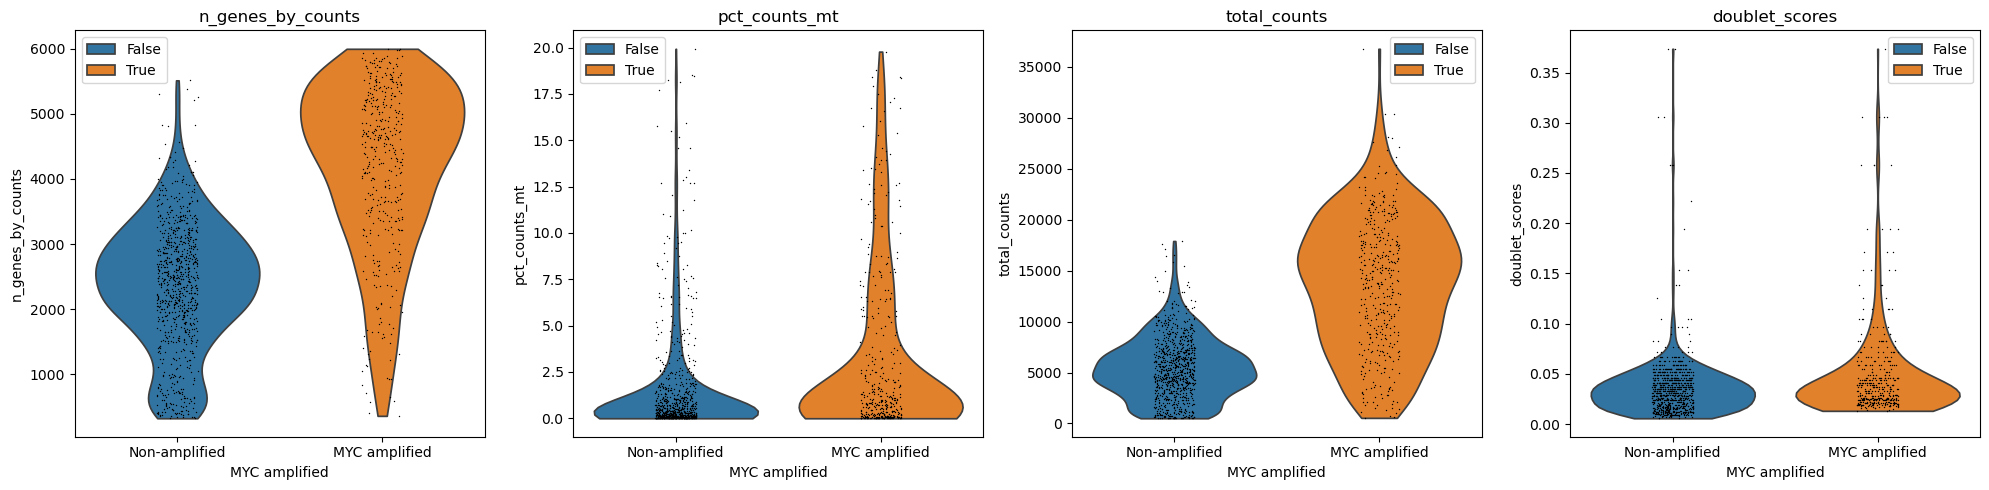

In [41]:
# compare QC metrics across cell subpopulations
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Convert boolean to categorical
myc_sample_adata.obs['MYC_amplified'] = myc_sample_adata.obs['MYC_amplified'].astype('category')

# n_genes_by_counts
sc.pl.violin(myc_sample_adata, keys='n_genes_by_counts', groupby='MYC_amplified', 
             ax=axes[0], show=False)
axes[0].set_title('n_genes_by_counts')
axes[0].set_xticklabels(['Non-amplified', 'MYC amplified'])

# Get mean n_genes_by_counts for each group
amp_mean = myc_sample_adata.obs.loc[myc_sample_adata.obs['MYC_amplified'] == True, 'n_genes_by_counts'].mean()
non_amp_mean = myc_sample_adata.obs.loc[myc_sample_adata.obs['MYC_amplified'] == False, 'n_genes_by_counts'].mean()

# Calculate fold change
fold_change = amp_mean / non_amp_mean
log2_fc = np.log2(fold_change)

print(f"MYC amplified mean: {amp_mean:.1f}")
print(f"Non-amplified mean: {non_amp_mean:.1f}")
print(f"Fold change: {fold_change:.3f}")
print(f"Log2 fold change: {log2_fc:.3f}")

# pct_counts_mt
sc.pl.violin(myc_sample_adata, keys='pct_counts_mt', groupby='MYC_amplified',
             ax=axes[1], show=False)
axes[1].set_title('pct_counts_mt')
axes[1].set_xticklabels(['Non-amplified', 'MYC amplified'])

# pct_counts
sc.pl.violin(myc_sample_adata, keys='total_counts', groupby='MYC_amplified',
             ax=axes[2], show=False)
axes[2].set_title('total_counts')
axes[2].set_xticklabels(['Non-amplified', 'MYC amplified'])

sc.pl.violin(myc_sample_adata, keys='doublet_scores', groupby='MYC_amplified',
             ax=axes[3], show=False)
axes[3].set_title('doublet_scores')
axes[3].set_xticklabels(['Non-amplified', 'MYC amplified'])

plt.tight_layout()
plt.show()

Created 25 windows:
Window 0-10Mb: 179 genes
Window 10-20Mb: 144 genes
Window 20-30Mb: 190 genes
Window 30-40Mb: 164 genes
Window 40-50Mb: 164 genes
Window 50-60Mb: 104 genes
Window 60-70Mb: 66 genes
Window 70-80Mb: 57 genes
Window 80-90Mb: 69 genes
Window 90-100Mb: 79 genes
Window 100-110Mb: 87 genes
Window 110-120Mb: 147 genes
Window 120-130Mb: 26 genes
Window 130-140Mb: 0 genes
Window 140-150Mb: 107 genes
Window 150-160Mb: 282 genes
Window 160-170Mb: 152 genes
Window 170-180Mb: 95 genes
Window 180-190Mb: 80 genes
Window 190-200Mb: 42 genes
Window 200-210Mb: 164 genes
Window 210-220Mb: 66 genes
Window 220-230Mb: 112 genes
Window 230-240Mb: 66 genes
Window 240-250Mb: 93 genes


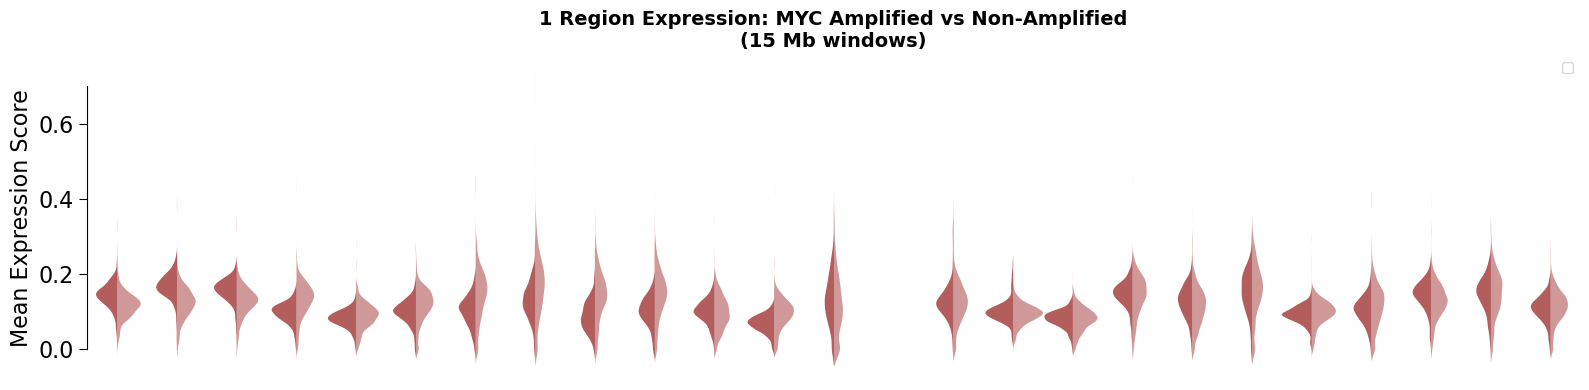

In [42]:
# Plot 15Mb windows across chromosome
window_size = 10_000_000
chrom_length = 250_000_000  # ~145 Mb for chr8
chromosome = 1

windows = []
for start in range(0, chrom_length, window_size):
    end = min(start + window_size, chrom_length)
    windows.append((start, end))

print(f"Created {len(windows)} windows:")

# Calculate region score for each window
window_scores = {}
for i, (start, end) in enumerate(windows):
    # Get genes in this window
    genes_in_window = gene_allelic_file[
        (gene_allelic_file["Chromosome/scaffold name"] == chromosome) &
        (gene_allelic_file["Gene start (bp)"] >= start) & 
        (gene_allelic_file["Gene end (bp)"] <= end)
    ]["Gene name"].dropna().tolist()
    
    genes_present = [g for g in genes_in_window if g in myc_sample_adata_norm.var_names]
    
    if len(genes_present) > 0:
        region_data = myc_sample_adata_norm[:, genes_present].X
        if hasattr(region_data, 'toarray'):
            region_data = region_data.toarray()
        window_scores[f"{int(start/1e6)}-{int(end/1e6)}Mb"] = region_data.mean(axis=1)
    else:
        window_scores[f"{int(start/1e6)}-{int(end/1e6)}Mb"] = np.zeros(myc_sample_adata_norm.n_obs)
    
    print(f"Window {int(start/1e6)}-{int(end/1e6)}Mb: {len(genes_present)} genes")

# Create DataFrame for plotting
plot_data = []
for window_name, scores in window_scores.items():
    for cell_idx, score in enumerate(scores):
        plot_data.append({
            'window': window_name,
            'score': score,
            'MYC_amplified': myc_sample_adata_norm.obs['MYC_amplified'].iloc[cell_idx]
        })
plot_df = pd.DataFrame(plot_data)

# Convert MYC_amplified to string for better labels
plot_df['MYC_status'] = plot_df['MYC_amplified'].map({True: 'MYC amp', False: 'Non-amp'})

# Order windows by genomic position
window_order = [f"{int(s/1e6)}-{int(e/1e6)}Mb" for s, e in windows]

# Plot
fig, ax = plt.subplots(figsize=(16, 4))

sns.violinplot(
    data=plot_df,
    x='window',
    y='score',
    hue='MYC_status',
    order=window_order,
    split=True,  # Side-by-side violins
    inner=None,
   # inner='quart',
    palette={"MYC amp": "#b22222", "Non-amp": "#b22222"},
    linewidth=0,
    width=1,
    ax=ax
)

polys = [c for c in ax.collections if isinstance(c, mcoll.PolyCollection)]
for i, pc in enumerate(polys):
  pc.set_alpha(0.8 if i % 2 == 0 else 0.5)

#ax.set_xlabel(f'Chromosome {chromosome} Position', fontsize=12)
ax.set_ylabel('Mean Expression Score', fontsize=16)
ax.set_title(f'{chromosome} Region Expression: MYC Amplified vs Non-Amplified\n(15 Mb windows)', fontsize=14, fontweight='bold')
# remove legend
ax.legend([])
ax.set_xlabel("")
#ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_xticks([])
ax.set_xticklabels([])

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)

fig.canvas.draw()

ticks = ax.get_yticks()
lo, hi = ax.get_ylim()
t = ticks[(ticks >= min(lo, hi)) & (ticks <= max(lo, hi))]
ax.spines["left"].set_bounds(t[0], t[-1])
ax.tick_params(axis="y", bottom=False, labelbottom=False, labelsize=16, length=6)

plt.tight_layout()
plt.savefig(f'../outputs/plots/{chromosome}_region_expression.pdf', bbox_inches='tight')
plt.show()

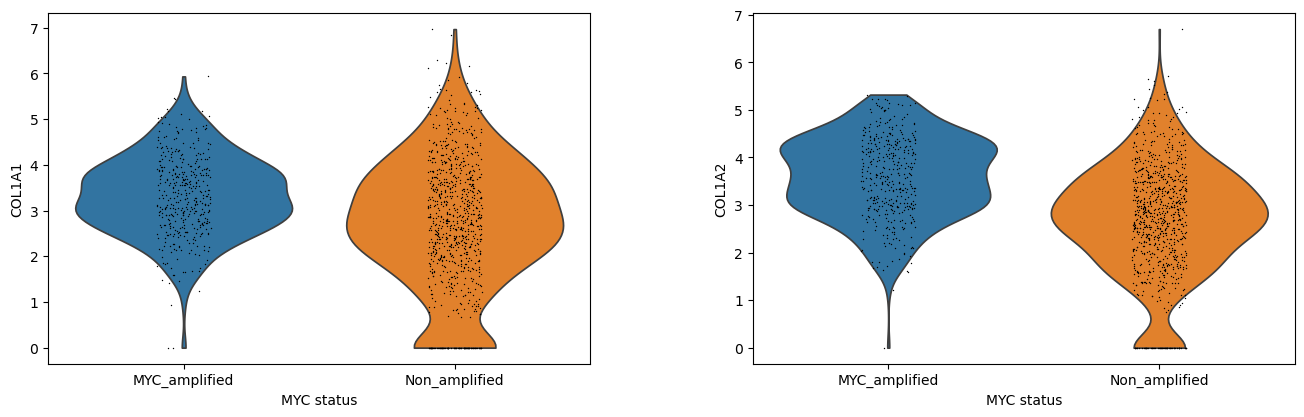

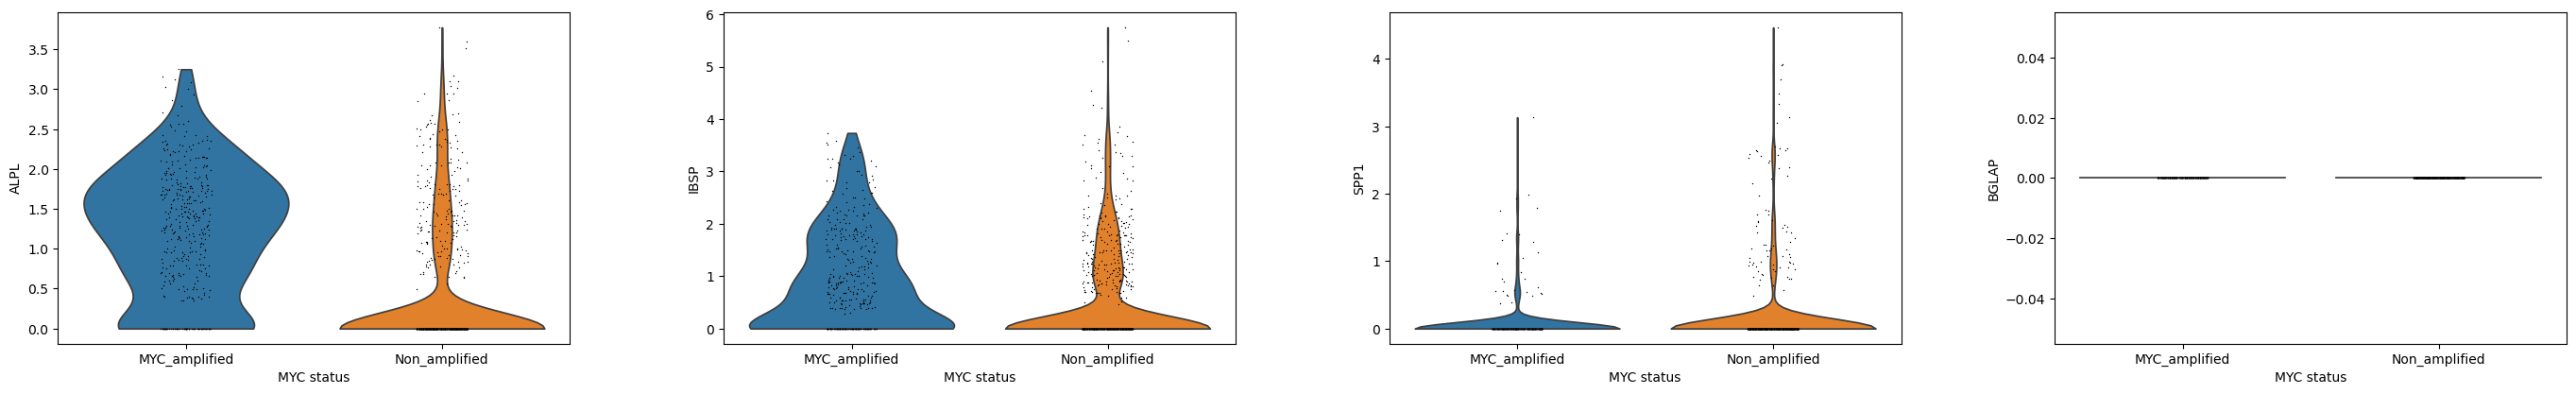

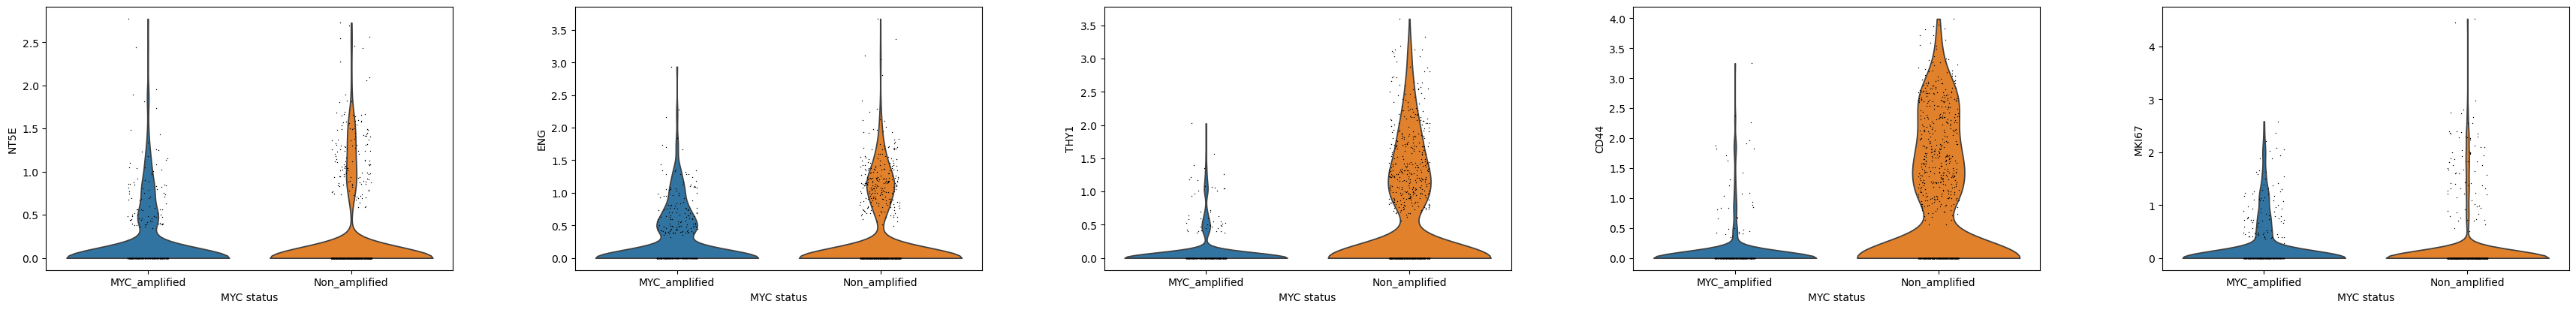

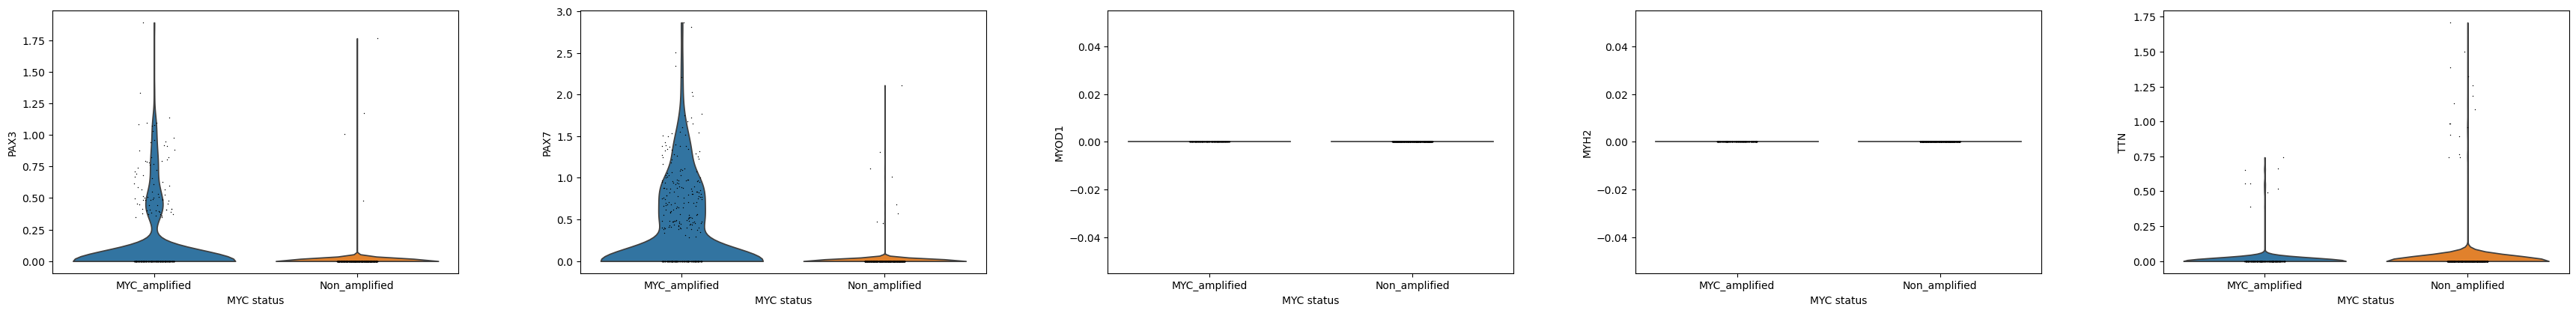

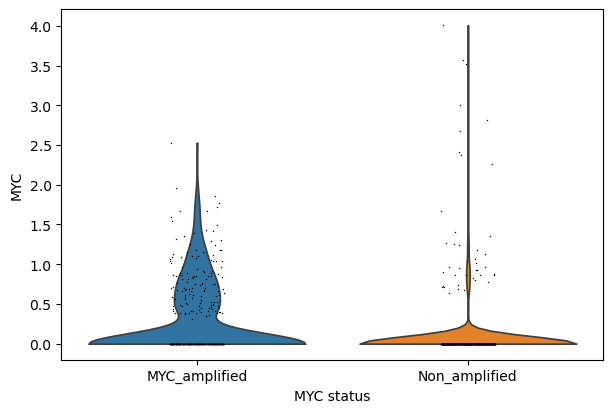

In [43]:
# visualize differences in marker genes
sc.pl.violin(myc_sample_adata_norm, keys=['COL1A1', 'COL1A2'], groupby='MYC_status')
sc.pl.violin(myc_sample_adata_norm, keys=['ALPL', 'IBSP', 'SPP1', 'BGLAP'], groupby='MYC_status')
sc.pl.violin(myc_sample_adata_norm, keys=['NT5E', 'ENG', 'THY1', 'CD44', 'MKI67'], groupby='MYC_status')
sc.pl.violin(myc_sample_adata_norm, keys=['PAX3', 'PAX7', 'MYOD1', 'MYH2', 'TTN'], groupby='MYC_status')
sc.pl.violin(myc_sample_adata_norm, keys=['MYC'], groupby='MYC_status')

# Analysis of TP53 upstream sample (CCG1106_075_T1) 
Prepare input files for cytotrace

In [44]:
sample_id = 'CCG1106_075_T1'
threshold = 0.2

# 1. Load raw counts
tp53_sample_adata = sc.read_h5ad("../../data/dfci/expression-data_scrna_dfci_tumor_expr_CCG1106_075_T1.h5ad")
print(f"Raw data shape: {tp53_sample_adata.shape}")

# 2. Normalize to calculate region scores
tp53_sample_adata_norm = tp53_sample_adata.copy()
sc.pp.normalize_total(tp53_sample_adata_norm, target_sum=1e4)
sc.pp.log1p(tp53_sample_adata_norm)

# 3. Calc TP53 upstream region score
region_chrom = 17
region_start = 7000000 
region_end = 22000000 

genes_in_region = gene_allelic_file[
    (gene_allelic_file["Chromosome/scaffold name"] == region_chrom) &
    (gene_allelic_file["Gene start (bp)"] <= region_end) & 
    (gene_allelic_file["Gene end (bp)"] >= region_start)
]
gene_names_list = genes_in_region["Gene name"].tolist()
gene_names_list = [g for g in gene_names_list if pd.notna(g)]
genes_in_data = [g for g in gene_names_list if g in tp53_sample_adata_norm.var_names]
print(f"Found {len(genes_in_data)} genes in TP53 upstream region")

# Calculate region score
region_data = tp53_sample_adata_norm[:, genes_in_data]
if hasattr(region_data.X, 'toarray'):
    mean_expr = region_data.X.toarray().mean(axis=1)
else:
    mean_expr = region_data.X.mean(axis=1)

# Add to raw adata 
tp53_sample_adata.obs['TP53_upstream_region_score'] = mean_expr
tp53_sample_adata.obs['TP53_upstream_amplified'] = mean_expr > threshold
print(f"\nTP53 amplified cells: {tp53_sample_adata.obs['TP53_upstream_amplified'].sum()}")
print(f"Non-amplified cells: {(~tp53_sample_adata.obs['TP53_upstream_amplified']).sum()}")

# Create expression matrix
expr_matrix = pd.DataFrame(
    tp53_sample_adata.X.toarray().T,
    index=tp53_sample_adata.var_names,
    columns=tp53_sample_adata.obs_names
)

# Create phenotype file
phenotype = pd.DataFrame({
    'cell_id': tp53_sample_adata.obs_names,
    'phenotype': tp53_sample_adata.obs['TP53_upstream_amplified'].map({
        True: 'TP53_upstream_amplified',
        False: 'Non_amplified'
    })
})

expr_matrix.to_csv(f'../../cytotrace/data/{sample_id}_TP53_expression_matrix_raw.txt', sep='\t')
phenotype.to_csv(f'../../cytotrace/data/{sample_id}_TP53_phenotype.txt', sep='\t', header=True, index=False)

Raw data shape: (1955, 26220)
Found 296 genes in TP53 upstream region

TP53 amplified cells: 1382
Non-amplified cells: 573


In [45]:
# Add group labels as category
tp53_sample_adata.obs['TP53_upstream_status'] = tp53_sample_adata.obs['TP53_upstream_amplified'].map({
    True: 'TP53_upstream_amplified', 
    False: 'Non_amplified'
}).astype('category')

# Normalize for DEG analysis
tp53_sample_adata_norm = tp53_sample_adata.copy()
sc.pp.normalize_total(tp53_sample_adata_norm, target_sum=1e4)
sc.pp.log1p(tp53_sample_adata_norm)

# Run differential expression (Wilcoxon rank-sum test)
sc.tl.rank_genes_groups(tp53_sample_adata_norm, groupby='TP53_upstream_status', method='wilcoxon', reference='Non_amplified')

# Get results as DataFrame
deg_results = sc.get.rank_genes_groups_df(tp53_sample_adata_norm, group='TP53_upstream_amplified')
deg_results.to_csv("../outputs/deg_analysis/TP53_upstream_amplified_vs_non_wilcoxon_DEGs.csv", index=False)

# Filter significant DEGs
sig_degs = deg_results[(deg_results['pvals_adj'] < 0.01) & (abs(deg_results['logfoldchanges']) > 1)]

print(f"Significant DEGs: {len(sig_degs)}")
print(f"  Upregulated in TP53 upstream amplified: {(sig_degs['logfoldchanges'] > 0).sum()}")
print(f"  Downregulated: {(sig_degs['logfoldchanges'] < 0).sum()}")

# Load the MYC region genes
tp53_region_genes = pd.read_csv("../data/TP53_upstream_genes_in_region.txt")['gene'].dropna().tolist()

# Add column indicating if gene is in region
sig_degs['in_TP53_upstream_region'] = sig_degs['names'].isin(tp53_region_genes)

# Check how many DEGs are in the region
print(f"DEGs in TP53 upstream region: {sig_degs['in_TP53_upstream_region'].sum()}")
print(f"DEGs outside TP53 upstream region: {(~sig_degs['in_TP53_upstream_region']).sum()}")
sig_degs.to_csv("../outputs/deg_analysis/TP53_upstream_amplified_vs_non_wilcoxon_sig_DEGs.csv", index=False)

Significant DEGs: 2706
  Upregulated in TP53 upstream amplified: 1849
  Downregulated: 857
DEGs in TP53 upstream region: 80
DEGs outside TP53 upstream region: 2626


/var/folders/l_/yt1nk3rj6rvgt0nnj_qtfs7m0000gn/T/ipykernel_879/393930636.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sig_degs['in_TP53_upstream_region'] = sig_degs['names'].isin(tp53_region_genes)


/var/folders/l_/yt1nk3rj6rvgt0nnj_qtfs7m0000gn/T/ipykernel_879/1235027415.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Non-amplified', 'TP53_upstream_amplified'])
/var/folders/l_/yt1nk3rj6rvgt0nnj_qtfs7m0000gn/T/ipykernel_879/1235027415.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Non-amplified', 'TP53_upstream_amplified'])
/var/folders/l_/yt1nk3rj6rvgt0nnj_qtfs7m0000gn/T/ipykernel_879/1235027415.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(['Non-amplified', 'TP53_upstream_amplified'])
/var/folders/l_/yt1nk3rj6rvgt0nnj_qtfs7m0000gn/T/ipykernel_879/1235027415.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of tic

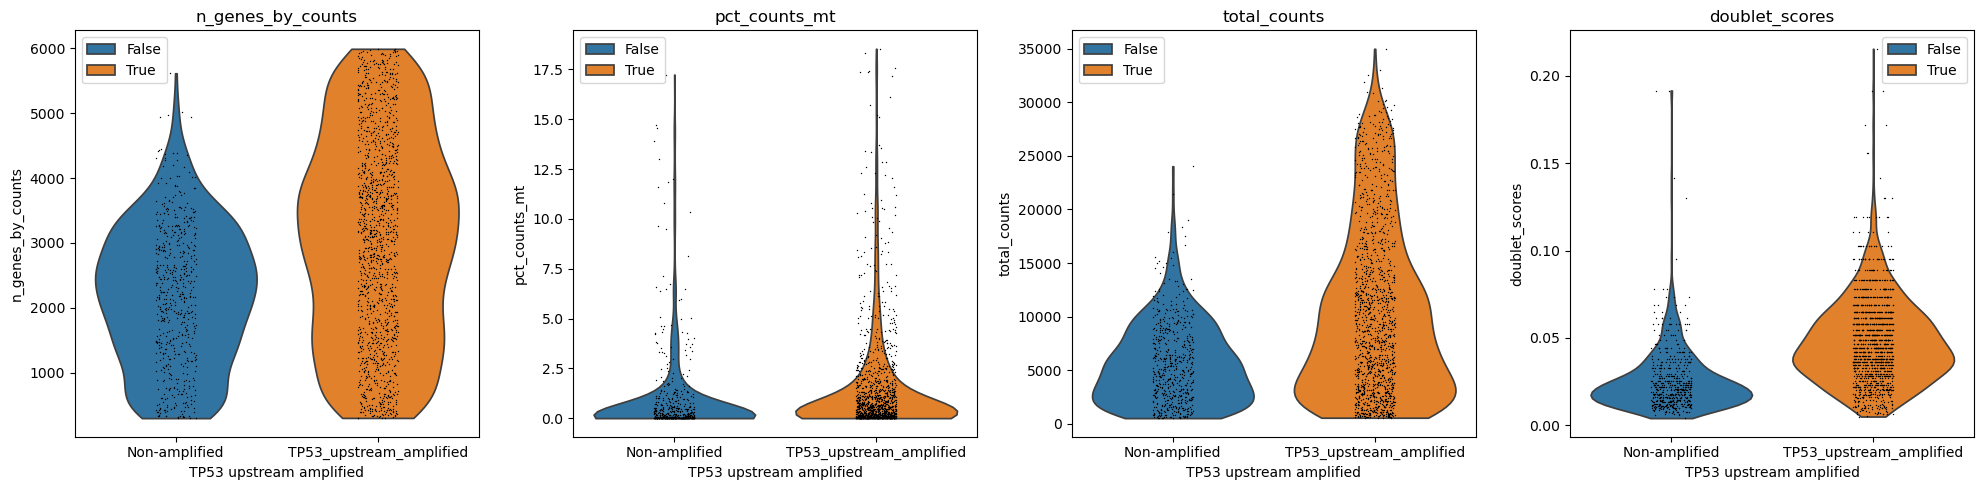

In [46]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Convert boolean to categorical
tp53_sample_adata.obs['TP53_upstream_amplified'] = tp53_sample_adata.obs['TP53_upstream_amplified'].astype('category')

# n_genes_by_counts
sc.pl.violin(tp53_sample_adata, keys='n_genes_by_counts', groupby='TP53_upstream_amplified', 
             ax=axes[0], show=False)
axes[0].set_title('n_genes_by_counts')
axes[0].set_xticklabels(['Non-amplified', 'TP53_upstream_amplified'])

# pct_counts_mt
sc.pl.violin(tp53_sample_adata, keys='pct_counts_mt', groupby='TP53_upstream_amplified',
             ax=axes[1], show=False)
axes[1].set_title('pct_counts_mt')
axes[1].set_xticklabels(['Non-amplified', 'TP53_upstream_amplified'])

# pct_counts_mt
sc.pl.violin(tp53_sample_adata, keys='total_counts', groupby='TP53_upstream_amplified',
             ax=axes[2], show=False)
axes[2].set_title('total_counts')
axes[2].set_xticklabels(['Non-amplified', 'TP53_upstream_amplified'])

sc.pl.violin(tp53_sample_adata, keys='doublet_scores', groupby='TP53_upstream_amplified',
             ax=axes[3], show=False)
axes[3].set_title('doublet_scores')
axes[3].set_xticklabels(['Non-amplified', 'TP53_upstream_amplified'])

plt.tight_layout()
plt.show()

Created 14 windows:
Window 1-11Mb: 75 genes
Window 11-21Mb: 74 genes
Window 21-31Mb: 75 genes
Window 31-41Mb: 50 genes
Window 41-51Mb: 119 genes
Window 51-61Mb: 33 genes
Window 61-71Mb: 77 genes
Window 71-81Mb: 111 genes
Window 81-91Mb: 76 genes
Window 91-101Mb: 133 genes
Window 101-111Mb: 87 genes
Window 111-121Mb: 73 genes
Window 121-131Mb: 67 genes
Window 131-133Mb: 15 genes


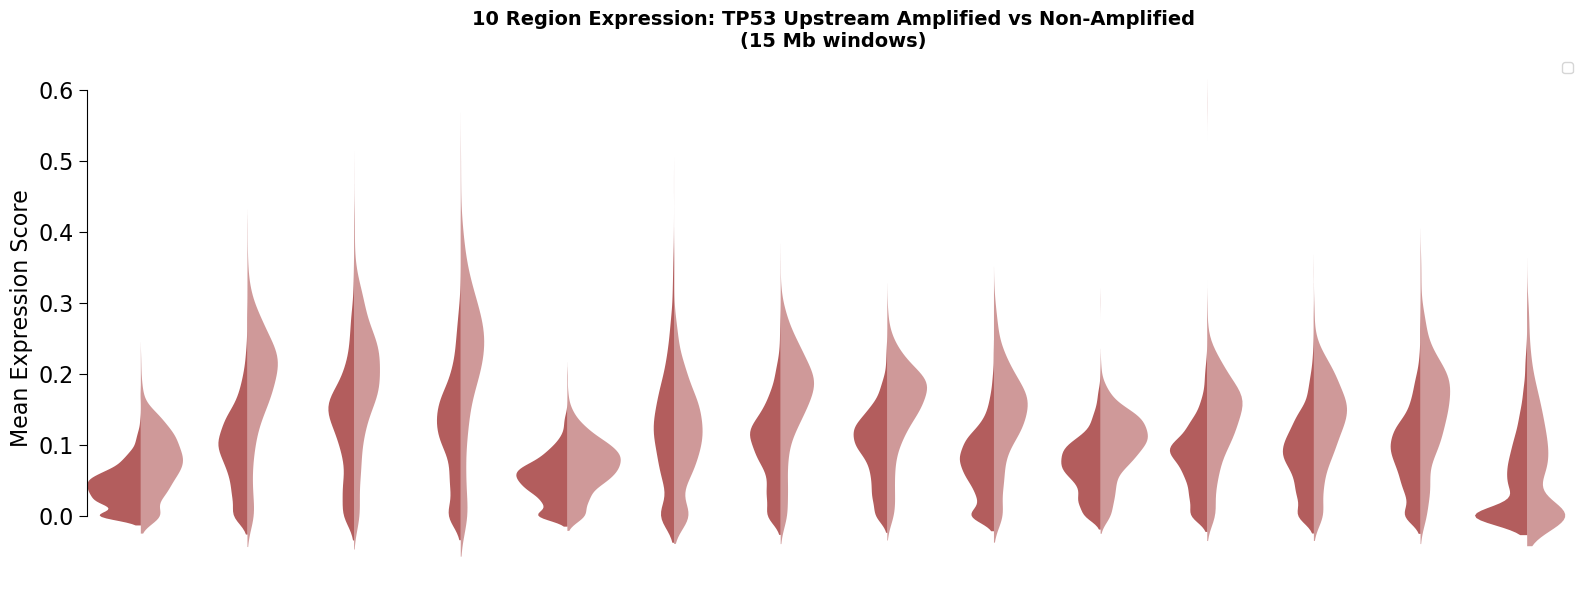

In [49]:
# Plot 15Mb windows across chromosome
window_size = 10_000_000  # 15 Mb
chrom_length = 133_000_000  # ~145 Mb for chr8
chromosome = 10

windows = []
for start in range(15_000_00, chrom_length, window_size):
    end = min(start + window_size, chrom_length)
    windows.append((start, end))
print(f"Created {len(windows)} windows:")

# Calculate region score for each window
window_scores = {}
for i, (start, end) in enumerate(windows):
    # Get genes in this window
    genes_in_window = gene_allelic_file[
        (gene_allelic_file["Chromosome/scaffold name"] == chromosome) &
        (gene_allelic_file["Gene start (bp)"] >= start) & 
        (gene_allelic_file["Gene end (bp)"] <= end)
    ]["Gene name"].dropna().tolist()
    
    genes_present = [g for g in genes_in_window if g in tp53_sample_adata_norm.var_names]
    
    if len(genes_present) > 0:
        region_data = tp53_sample_adata_norm[:, genes_present].X
        if hasattr(region_data, 'toarray'):
            region_data = region_data.toarray()
        window_scores[f"{int(start/1e6)}-{int(end/1e6)}Mb"] = region_data.mean(axis=1)
    else:
        window_scores[f"{int(start/1e6)}-{int(end/1e6)}Mb"] = np.zeros(tp53_sample_adata_norm.n_obs)
    
    print(f"Window {int(start/1e6)}-{int(end/1e6)}Mb: {len(genes_present)} genes")

# Create DataFrame for plotting
plot_data = []
for window_name, scores in window_scores.items():
    for cell_idx, score in enumerate(scores):
        plot_data.append({
            'window': window_name,
            'score': score,
            'TP53_upstream_amplified': tp53_sample_adata_norm.obs['TP53_upstream_amplified'].iloc[cell_idx]
        })

plot_df = pd.DataFrame(plot_data)

plot_df['TP53_upstream_status'] = plot_df['TP53_upstream_amplified'].map({True: 'TP53 upstream amp', False: 'Non-amp'})

# Order windows by genomic position
window_order = [f"{int(s/1e6)}-{int(e/1e6)}Mb" for s, e in windows]

# Plot
fig, ax = plt.subplots(figsize=(16, 6))

sns.violinplot(
    data=plot_df,
    x='window',
    y='score',
    hue='TP53_upstream_status',
    order=window_order,
    split=True,  # Side-by-side violins
    inner=None,
   # inner='quart',
    palette={"TP53 upstream amp": "#b22222", "Non-amp": "#b22222"},
    linewidth=0,
    width=1,
    ax=ax
)

polys = [c for c in ax.collections if isinstance(c, mcoll.PolyCollection)]
for i, pc in enumerate(polys):
  pc.set_alpha(0.8 if i % 2 == 0 else 0.5)

#ax.set_xlabel(f'Chromosome {chromosome} Position', fontsize=12)
ax.set_ylabel('Mean Expression Score', fontsize=16)
ax.set_title(f'{chromosome} Region Expression: TP53 Upstream Amplified vs Non-Amplified\n(15 Mb windows)', 
             fontsize=14, fontweight='bold')

# remove legend
ax.legend([])
ax.set_xlabel("")
#ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_xticks([])
ax.set_xticklabels([])

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)

fig.canvas.draw()

ticks = ax.get_yticks()
lo, hi = ax.get_ylim()
t = ticks[(ticks >= min(lo, hi)) & (ticks <= max(lo, hi))]
ax.spines["left"].set_bounds(t[0], t[-1])
ax.tick_params(axis="y", bottom=False, labelbottom=False, labelsize=16, length=6)

plt.tight_layout()
plt.savefig(f'../outputs/plots/{chromosome}_region_expression.pdf', bbox_inches='tight')
plt.show()


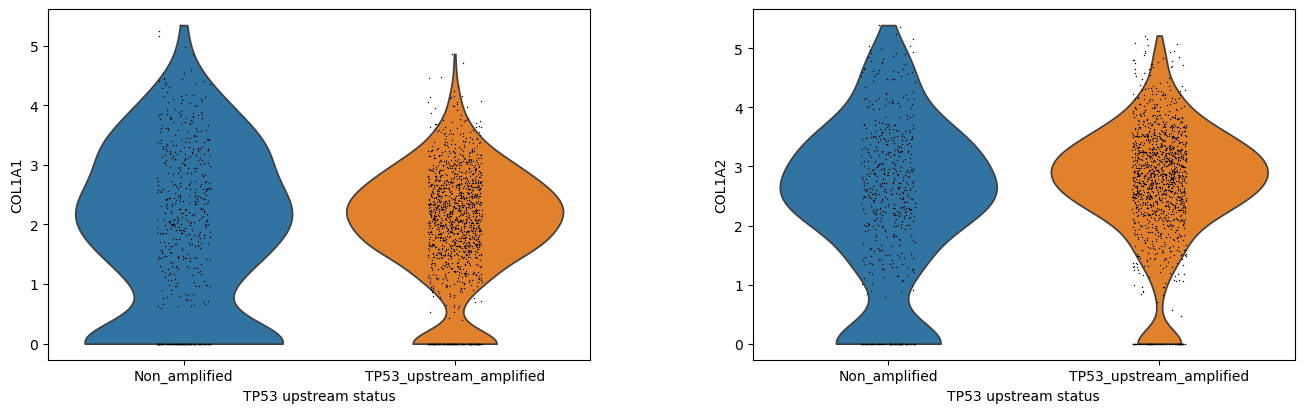

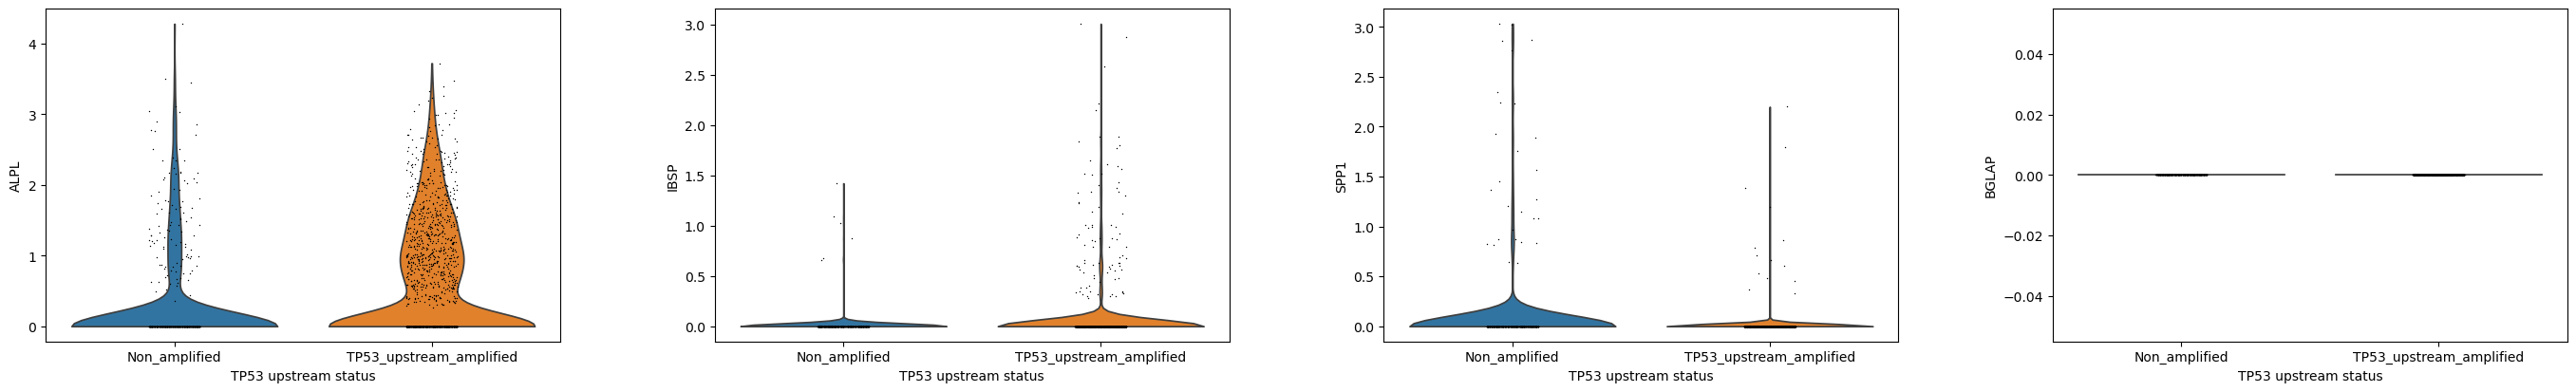

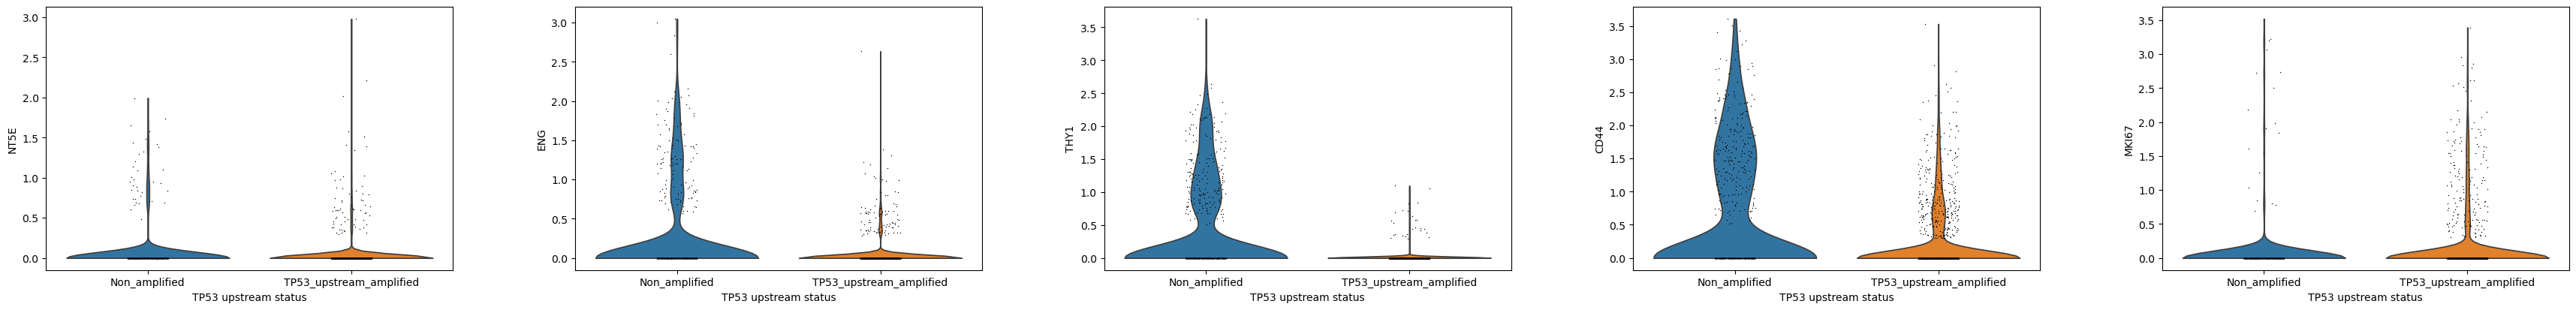

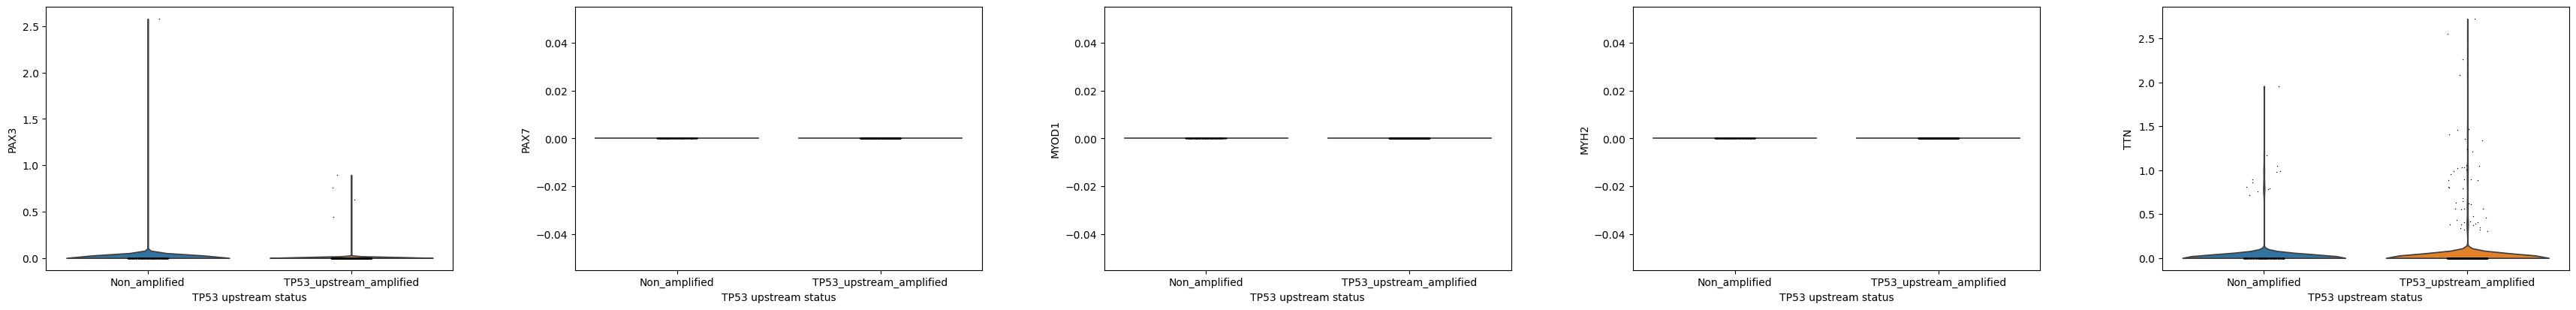

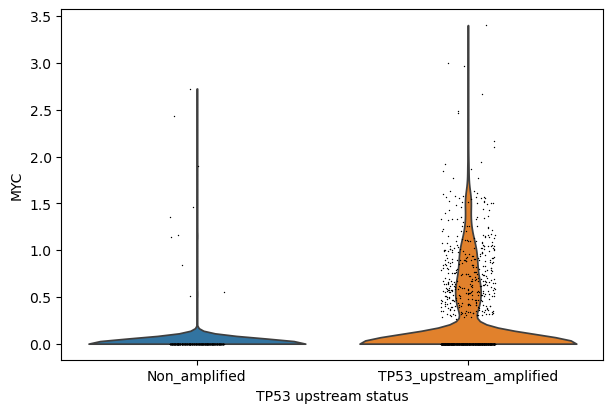

In [19]:
sc.pl.violin(tp53_sample_adata_norm, keys=['COL1A1', 'COL1A2'], groupby='TP53_upstream_status')
sc.pl.violin(tp53_sample_adata_norm, keys=['ALPL', 'IBSP', 'SPP1', 'BGLAP'], groupby='TP53_upstream_status')
sc.pl.violin(tp53_sample_adata_norm, keys=['NT5E', 'ENG', 'THY1', 'CD44', 'MKI67'], groupby='TP53_upstream_status')
sc.pl.violin(tp53_sample_adata_norm, keys=['PAX3', 'PAX7', 'MYOD1', 'MYH2', 'TTN'], groupby='TP53_upstream_status')
sc.pl.violin(tp53_sample_adata_norm, keys=['MYC'], groupby='TP53_upstream_status')